In [2]:
import pandas as pd

train = pd.read_csv(r"C:\研究所\深度學習\zip.train.csv")
test  = pd.read_csv(r"C:\研究所\深度學習\zip.test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (7290, 258)
Test shape: (2006, 257)


,A1,6,-1.0,-1.0.1,-1.0.2,-1.0.3,-1.0.4,-1.0.5,-1.0.6,-0.631,...,0.304,0.823,1.0.39,0.482,-0.474,-0.991,-1.0.121,-1.0.122,-1.0.123,-1.0.124
0,A2,5,-1.0,-1.0,-1.0,-0.813,-0.671,-0.809,-0.887,-0.671,...,-0.671,-0.671,-0.033,0.761,0.762,0.126,-0.095,-0.671,-0.828,-1.0
1,A3,4,-1.0,-1.0,-1.0,-1.000,-1.000,-1.000,-1.000,-1.000,...,-1.000,-1.000,-1.000,-0.109,1.000,-0.179,-1.000,-1.000,-1.000,-1.0
2,A4,7,-1.0,-1.0,-1.0,-1.000,-1.000,-0.273,0.684,0.960,...,-0.318,1.000,0.536,-0.987,-1.000,-1.000,-1.000,-1.000,-1.000,-1.0
3,A5,3,-1.0,-1.0,-1.0,-1.000,-1.000,-0.928,-0.204,0.751,...,0.466,0.639,1.000,1.000,0.791,0.439,-0.199,-0.883,-1.000,-1.0
4,A6,6,-1.0,-1.0,-1.0,-1.000,-1.000,-0.397,0.983,-0.535,...,0.803,0.015,-0.862,-0.871,-0.437,-1.000,-1.000,-1.000,-1.000,-1.0


各數字樣本數：
Digit 0: 1194
Digit 1: 1005
Digit 2: 731
Digit 3: 658
Digit 4: 652
Digit 5: 556
Digit 6: 663
Digit 7: 645
Digit 8: 542
Digit 9: 644


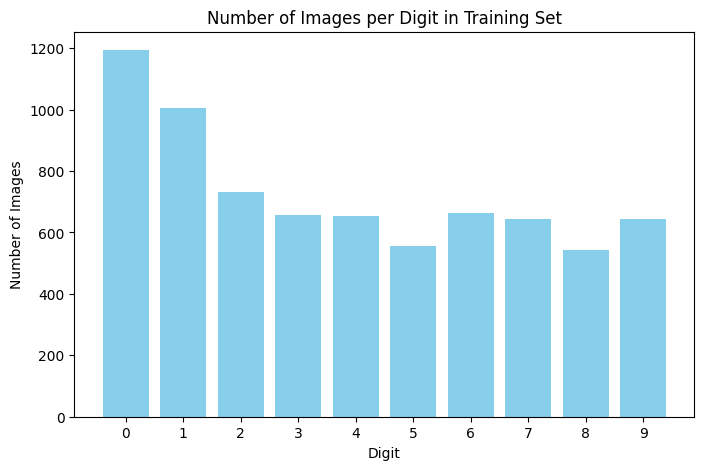

In [3]:
import matplotlib.pyplot as plt

# 假設 train 的第二欄就是 Label (digit id)
labels = train.iloc[:, 1]

# 計算各個數字的數量
counts = labels.value_counts().sort_index()

# 顯示數字的樣本數
print("各數字樣本數：")
for digit, cnt in counts.items():
    print(f"Digit {digit}: {cnt}")

# 畫長條圖
plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values, color="skyblue")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Number of Images per Digit in Training Set")
plt.xticks(range(10))  # 確保 X 軸顯示 0-9
plt.show()


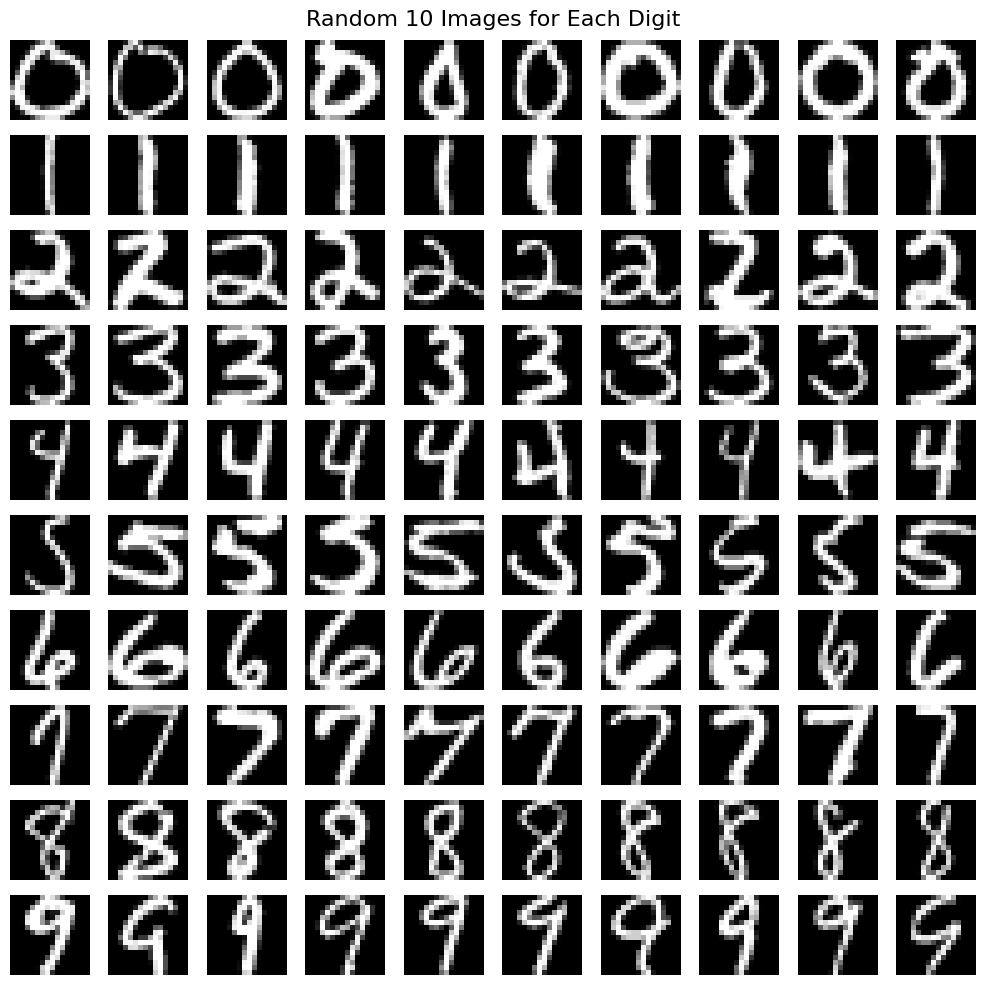

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# label 在第 1 欄，像素從第 2 欄開始
labels = train.iloc[:, 1]
pixels = train.iloc[:, 2:]

# 畫圖
fig, axes = plt.subplots(10, 10, figsize=(10, 10))  # 10 個數字，每個數字 10 張圖

for digit in range(10):
    # 抽取該數字的 index
    digit_indices = labels[labels == digit].index
    sample_indices = np.random.choice(digit_indices, 10, replace=False)
    
    for j, idx in enumerate(sample_indices):
        ax = axes[digit, j]
        img = pixels.loc[idx].values.reshape(16, 16)  # reshape 成 16x16
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if j == 0:   # 每一行最左邊標記數字
            ax.set_ylabel(str(digit), fontsize=12, rotation=0, labelpad=10)

plt.suptitle("Random 10 Images for Each Digit", fontsize=16)
plt.tight_layout()
plt.show()


In [5]:
# === 0) 準備資料 (labels 在第1欄，像素從第2欄開始) ===
import numpy as np
from sklearn.model_selection import train_test_split

X = train.iloc[:, 2:].to_numpy(dtype="float32")   # 256 個像素
y = train.iloc[:, 1].to_numpy(dtype="int64")      # digit id 0-9

# 正規化：若發現像素最大值 > 1，則視為 0~255 灰階，縮放到 0~1
if np.nanmax(X) > 1.0:
    X = X / 255.0

# 依作業要求切 80/20 當 train/val
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === 1) 定義五個網路 ===
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

def make_model(hidden_layers, input_dim=256, num_classes=10, lr=1e-3):
    model = Sequential([Input(shape=(input_dim,))])
    for units in hidden_layers:
        model.add(Dense(units, activation="relu"))
    model.add(Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

nets = {
    "net1": make_model([12]),
    "net2": make_model([64, 16]),
    "net3": make_model([64, 64, 16]),
    "net4": make_model([64, 64, 16, 16]),
    "net5": make_model([128, 64, 16, 16]),
}

# 顯示各模型參數量（之後作業要用得到）
def count_params(model):
    return int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))

for name, mdl in nets.items():
    print(f"{name}: params = {count_params(mdl):,}")
    # mdl.summary()  # 需要更詳細架構時再打開
print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)


net1: params = 3,214
net2: params = 17,658
net3: params = 21,818
net4: params = 22,090
net5: params = 42,634
X_tr: (5832, 256) y_tr: (5832,)
X_val: (1458, 256) y_val: (1458,)


Scanning net1 ...
Scanning net2 ...
Scanning net3 ...
Scanning net4 ...
Scanning net5 ...


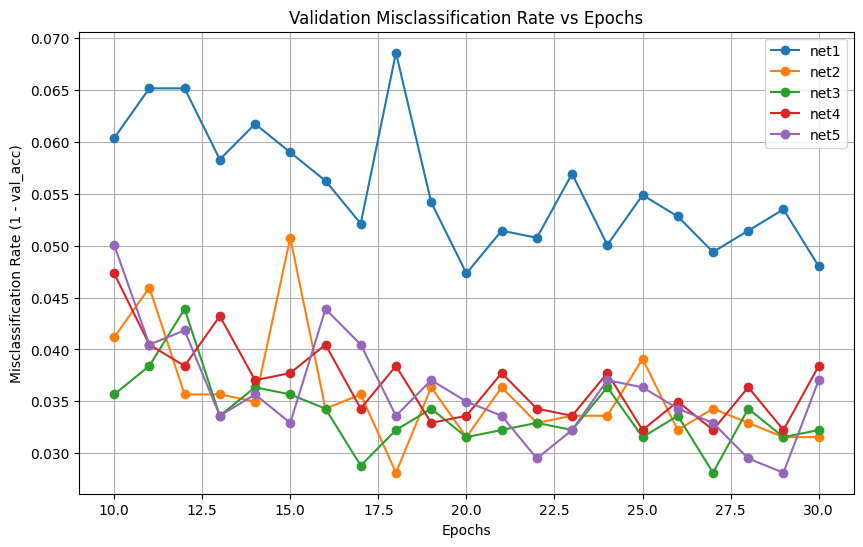

Best epochs: {'net1': 20, 'net2': 18, 'net3': 27, 'net4': 25, 'net5': 29}


In [10]:
import matplotlib.pyplot as plt

def scan_epochs(net_name, epochs_range=range(10, 31), batch_size=128):
    results = []
    for ep in epochs_range:
        # 每次都要重新建新模型，避免沿用舊權重
        hidden_dict = {
            "net1": [12],
            "net2": [64, 16],
            "net3": [64, 64, 16],
            "net4": [64, 64, 16, 16],
            "net5": [128, 64, 16, 16],
        }
        model = make_model(hidden_dict[net_name])
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=ep,
            batch_size=batch_size,
            verbose=0
        )
        val_acc = history.history["val_accuracy"][-1]
        val_err = 1 - val_acc
        results.append((ep, val_err))
    return results

# 掃描所有模型
all_results = {}
for net in nets.keys():
    print(f"Scanning {net} ...")
    all_results[net] = scan_epochs(net)

# 畫圖
plt.figure(figsize=(10,6))
for net, res in all_results.items():
    epochs = [r[0] for r in res]
    val_errs = [r[1] for r in res]
    plt.plot(epochs, val_errs, marker="o", label=net)

plt.xlabel("Epochs")
plt.ylabel("Misclassification Rate (1 - val_acc)")
plt.title("Validation Misclassification Rate vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

# 找最佳 epoch
best_epochs = {net: min(res, key=lambda x: x[1])[0] for net, res in all_results.items()}
print("Best epochs:", best_epochs)


In [11]:
# 最終模型若已訓練可跳過；否則這格會用 net5@23epochs 重新訓練並做預測
import numpy as np
import pandas as pd

# 取測試集 features 與 ID
X_test = test.iloc[:, 1:].to_numpy(dtype="float32")
test_ids = test.iloc[:, 0].astype(str).to_numpy()  # 重要：確保是字串，例如 'B1'

# 正規化（若像素為 0~255）
if np.nanmax(X_test) > 1.0:
    X_test = X_test / 255.0

# 若沒有 y_pred，就用現成的 final_model or 直接重建並訓練
need_pred = "y_pred" not in globals()
if need_pred:
    if "final_model" not in globals():
        from tensorflow.keras import Sequential
        from tensorflow.keras.layers import Dense, Input
        from tensorflow.keras.optimizers import Adam

        def make_model(hidden_layers, input_dim=256, num_classes=10, lr=1e-3):
            m = Sequential([Input(shape=(input_dim,))])
            for u in hidden_layers:
                m.add(Dense(u, activation="relu"))
            m.add(Dense(num_classes, activation="softmax"))
            m.compile(optimizer=Adam(learning_rate=lr),
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])
            return m

        # 用 net5 結構
        final_model = make_model([128, 64, 16, 16])

        # 全訓練集
        X_full = train.iloc[:, 2:].to_numpy(dtype="float32")
        y_full = train.iloc[:, 1].to_numpy(dtype="int64")
        if np.nanmax(X_full) > 1.0:
            X_full = X_full / 255.0

        final_model.fit(X_full, y_full, epochs=23, batch_size=128, verbose=1)

    probs = final_model.predict(X_test, batch_size=512, verbose=1)
    y_pred = probs.argmax(axis=1)


Epoch 1/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5893 - loss: 1.2988  
Epoch 2/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9034 - loss: 0.3422  
Epoch 3/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9491 - loss: 0.1998 
Epoch 4/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9568 - loss: 0.1577 
Epoch 5/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9687 - loss: 0.1162  
Epoch 6/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9770 - loss: 0.0897 
Epoch 7/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9802 - loss: 0.0743 
Epoch 8/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9833 - loss: 0.0635  
Epoch 9/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9893 - loss: 0.0468
Epoch 10/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9904 - loss: 0.0424  
Epoch 11/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9940 - loss: 0.0313 
Epoch 12/23
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accura

In [13]:
import pandas as pd

# 保證 test_ids 是字串陣列
test_ids = test.iloc[:, 0].astype(str).to_numpy()

# 檢查長度
print("len(test_ids) =", len(test_ids))
print("len(y_pred)   =", len(y_pred))
assert len(test_ids) == len(y_pred), "❌ 長度不一致，檢查模型或資料!"

# 正確建 DataFrame：必須給定 index，避免自動丟掉第一筆
sub = pd.DataFrame({
    "ID": pd.Series(test_ids, index=range(len(test_ids))),
    "Class": pd.Series(y_pred.astype(int), index=range(len(y_pred)))
})

print("✅ 輸出形狀:", sub.shape)
print(sub.head())

# 輸出 Kaggle 格式
sub.to_csv("test.digit.csv", index=False)


len(test_ids) = 2006
len(y_pred)   = 2006
✅ 輸出形狀: (2006, 2)
   ID  Class
0  B2      6
1  B3      3
2  B4      6
3  B5      6
4  B6      0


In [17]:
# === Final one-cell: re-read test, predict, write Kaggle CSV (ID,Class) ===
import numpy as np, pandas as pd
from pathlib import Path

# 1) Re-read test with header=None  (← 關鍵)
test_path = r"C:\研究所\深度學習\zip.test.csv"   # ← 換成你的實際路徑
test = pd.read_csv(test_path, header=None)
print("test shape:", test.shape)
print("test first 5 IDs:", test.iloc[:5, 0].astype(str).tolist())

# 2) Build features/ids
X_test  = test.iloc[:, 1:].to_numpy(dtype="float32")
test_ids = test.iloc[:, 0].astype(str).to_numpy()
if np.nanmax(X_test) > 1.0:
    X_test /= 255.0

# 3) Ensure we have a trained final_model; otherwise rebuild net5@23
need_model = "final_model" not in globals()
if need_model:
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Input
    from tensorflow.keras.optimizers import Adam

    def make_model(hidden_layers, input_dim=256, num_classes=10, lr=1e-3):
        m = Sequential([Input(shape=(input_dim,))])
        for u in hidden_layers:
            m.add(Dense(u, activation="relu"))
        m.add(Dense(num_classes, activation="softmax"))
        m.compile(optimizer=Adam(learning_rate=lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
        return m

    # rebuild training set from existing 'train' DF
    X_full = train.iloc[:, 2:].to_numpy(dtype="float32")
    y_full = train.iloc[:, 1].to_numpy(dtype="int64")
    if np.nanmax(X_full) > 1.0:
        X_full /= 255.0

    final_model = make_model([128, 64, 16, 16])  # net5
    final_model.fit(X_full, y_full, epochs=23, batch_size=128, verbose=1)
    print("Rebuilt and trained final_model (net5, 23 epochs).")

# 4) Fresh predictions (always recompute to避免舊的 y_pred 長度不符)
probs = final_model.predict(X_test, batch_size=512, verbose=1)
y_pred = probs.argmax(axis=1)

print("len(test_ids) =", len(test_ids))
print("len(y_pred)   =", len(y_pred))
assert len(test_ids) == len(y_pred), "長度不一致，請檢查！"

# 5) Write Kaggle file with header 'ID,Class'
sub = pd.DataFrame({"ID": test_ids, "Class": y_pred.astype(int)})
sub.to_csv("test.digit.csv", index=False)
print("✅ Wrote test.digit.csv with shape:", sub.shape)
print(sub.head().to_string(index=False))


test shape: (2007, 257)
test first 5 IDs: ['B1', 'B2', 'B3', 'B4', 'B5']
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
len(test_ids) = 2007
len(y_pred)   = 2007
✅ Wrote test.digit.csv with shape: (2007, 2)
ID  Class
B1      9
B2      6
B3      3
B4      6
B5      6


In [18]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

# 可重現
np.random.seed(42)
tf.random.set_seed(42)

# ── 訓練資料：第0欄 image id，第1欄 digit，第2~257欄像素 ──
X = train.iloc[:, 2:].to_numpy(dtype="float32")
y = train.iloc[:, 1].to_numpy(dtype="int64")

# 0~1 正規化（原始 0~255）
if np.nanmax(X) > 1.0:
    X = X / 255.0

# 80/20 切分（作業 Q5a）
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 測試資料（一定要 header=None 讀進來，避免吃掉 B1）──
# 若你已經有 test 這個 DataFrame，就不需要重讀；否則取消下一行註解，改成你的路徑
# test = pd.read_csv(r"C:\研究所\深度學習\zip.test.csv", header=None)

X_test  = test.iloc[:, 1:].to_numpy(dtype="float32")
test_ids = test.iloc[:, 0].astype(str).to_numpy()
if np.nanmax(X_test) > 1.0:
    X_test = X_test / 255.0

print("Train/Val shapes:", X_tr.shape, X_val.shape)
print("Test shape:", X_test.shape, "First 5 IDs:", test_ids[:5])


Train/Val shapes: (5832, 256) (1458, 256)
Test shape: (2007, 256) First 5 IDs: ['B1' 'B2' 'B3' 'B4' 'B5']


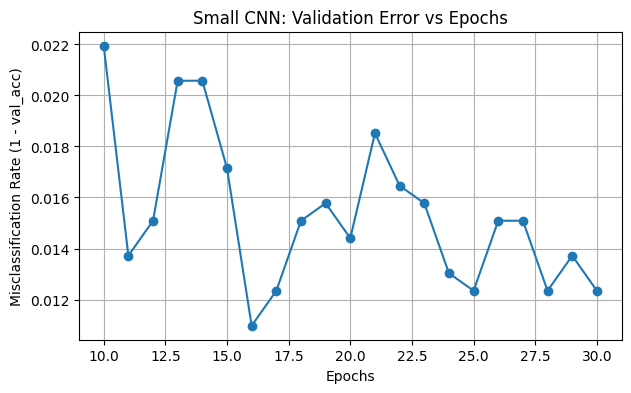

Small CNN params: 18,394
Best epoch in 10..30: 16


In [19]:
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import (Input, Reshape, Conv2D, MaxPooling2D,
                                     BatchNormalization, Dropout, Flatten, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

def make_small_cnn(lr=8e-4, drop=0.30, l2=0.0):
    m = Sequential([
        Input(shape=(256,)),
        Reshape((16,16,1)),

        Conv2D(8, (3,3), activation="relu", padding="same",
               kernel_regularizer=regularizers.l2(l2)),
        BatchNormalization(),
        MaxPooling2D((2,2)),      # -> 8x8x8

        Conv2D(16, (3,3), activation="relu", padding="same",
               kernel_regularizer=regularizers.l2(l2)),
        BatchNormalization(),
        MaxPooling2D((2,2)),      # -> 4x4x16

        Dropout(drop),
        Flatten(),                # -> 256

        Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2)),
        Dropout(drop/2),

        Dense(10, activation="softmax"),
    ])
    m.compile(optimizer=Adam(lr), loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

def count_params(model):
    import numpy as np
    return int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))

# 掃 epochs：10..30，記錄驗證錯誤率
epochs_range = range(10, 31)
val_errs = []
for ep in epochs_range:
    model = make_small_cnn()
    cb = [
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=0),
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=0),
    ]
    h = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=ep, batch_size=64, verbose=0, callbacks=cb)
    val_acc = h.history["val_accuracy"][-1]
    val_errs.append(1 - val_acc)

best_epoch = int(epochs_range[int(np.argmin(val_errs))])

plt.figure(figsize=(7,4))
plt.plot(list(epochs_range), val_errs, marker="o")
plt.xlabel("Epochs"); plt.ylabel("Misclassification Rate (1 - val_acc)")
plt.title("Small CNN: Validation Error vs Epochs")
plt.grid(True); plt.show()

tmp_model = make_small_cnn()
print("Small CNN params:", f"{count_params(tmp_model):,}")
print("Best epoch in 10..30:", best_epoch)


In [20]:
# 全訓練集（80/20 合併）重訓
X_full = train.iloc[:, 2:].to_numpy(dtype="float32")
y_full = train.iloc[:, 1].to_numpy(dtype="int64")
if np.nanmax(X_full) > 1.0:
    X_full = X_full / 255.0

final_model = make_small_cnn()
history = final_model.fit(X_full, y_full,
                          epochs=best_epoch, batch_size=64, verbose=1)

# 參數總數（報告 Q8d 會用）
print("Final Small CNN params:", f"{final_model.count_params():,}")

# 測試集預測
probs = final_model.predict(X_test, batch_size=512, verbose=1)
y_pred = probs.argmax(axis=1)

# 長度檢查
assert len(test_ids) == len(y_pred), f"length mismatch: {len(test_ids)} vs {len(y_pred)}"

# 輸出 Kaggle 檔（含表頭 ID,Class）
sub = pd.DataFrame({"ID": test_ids, "Class": y_pred.astype(int)})
sub.to_csv("test.digit.csv", index=False)

print("✅ Wrote test.digit.csv", sub.shape)
print(sub.head().to_string(index=False))


Epoch 1/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6553 - loss: 1.0968
Epoch 2/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8952 - loss: 0.3334
Epoch 3/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9292 - loss: 0.2183
Epoch 4/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9502 - loss: 0.1604
Epoch 5/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9602 - loss: 0.1402
Epoch 6/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9642 - loss: 0.1153
Epoch 7/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9669 - loss: 0.1048
Epoch 8/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9734 - loss: 0.0840
Epoch 9/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9753 - loss: 0.0779
Epoch 10/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9787 - loss: 0.0694
Epoch 11/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9804 - loss: 0.0605
Epoch 12/16
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step